In [2]:
!pip install plotly scikit-learn

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


### 1️⃣Top 10 brands by average price (interactive bar chart)

In [23]:
import pandas as pd
import plotly.express as px

# Load your cleaned dataset (update the path if needed)
data= pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")

print("Dataset loaded successfully:", data.shape)
data.head()


Dataset loaded successfully: (930, 15)


,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


In [27]:
print(data.columns.tolist())


['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)', 'Launched Price (India)', 'Launched Price (China)', 'Launched Price (USA)', 'Launched Price (Dubai)', 'Launched Year']


In [33]:
import pandas as pd
import plotly.express as px
import re

# If you haven't loaded data:
data =pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")

# Clean up the 'Launched Price (India)' column and make it numeric
def clean_price(x):
    if pd.isna(x): 
        return None
    # remove currency text, commas, and extra spaces
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)
    try:
        return float(x)
    except:
        return None

data["Launched Price (India)"] = data["Launched Price (India)"].apply(clean_price)

print("✅ Cleaned successfully!")
print(data["Launched Price (India)"].head(10))


✅ Cleaned successfully!
0     79999.0
1     84999.0
2     89999.0
3     89999.0
4     94999.0
5    104999.0
6     99999.0
7    104999.0
8    114999.0
9    109999.0
Name: Launched Price (India), dtype: float64


In [35]:
data["Launched Price (India)"].describe()


count       930.000000
mean      50576.818280
std       40960.179361
min        5999.000000
25%       19999.000000
50%       34999.000000
75%       74900.000000
max      274999.000000
Name: Launched Price (India), dtype: float64

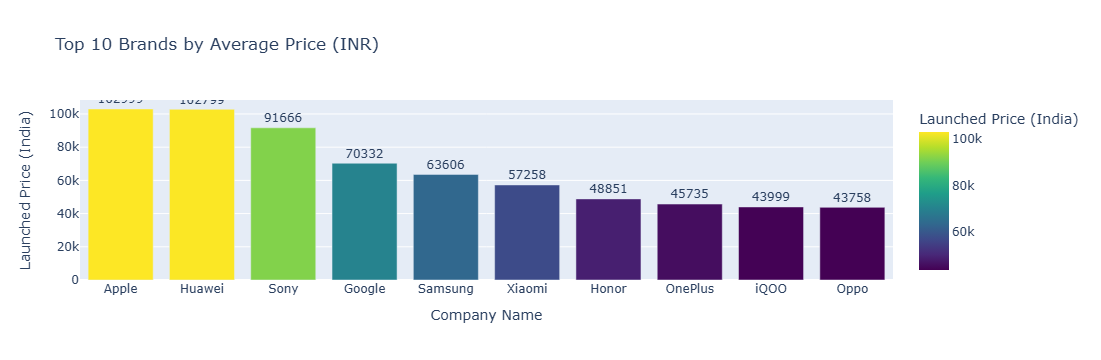

In [37]:
avg_price = (
    data.groupby("Company Name")["Launched Price (India)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    avg_price,
    x="Company Name",
    y="Launched Price (India)",
    color="Launched Price (India)",
    color_continuous_scale="Viridis",
    title="Top 10 Brands by Average Price (INR)",
    text="Launched Price (India)"
)

fig.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig.show()


In [41]:
data = data.rename(columns={
    "Launched Price (India)": "Price_INR",
    "Launched Price (Pakistan)": "Price_PKR",
    "Launched Price (China)": "Price_CNY",
    "Launched Price (USA)": "Price_USD",
    "Launched Price (Dubai)": "Price_AED"
})

### 2️⃣ Distribution of phone prices

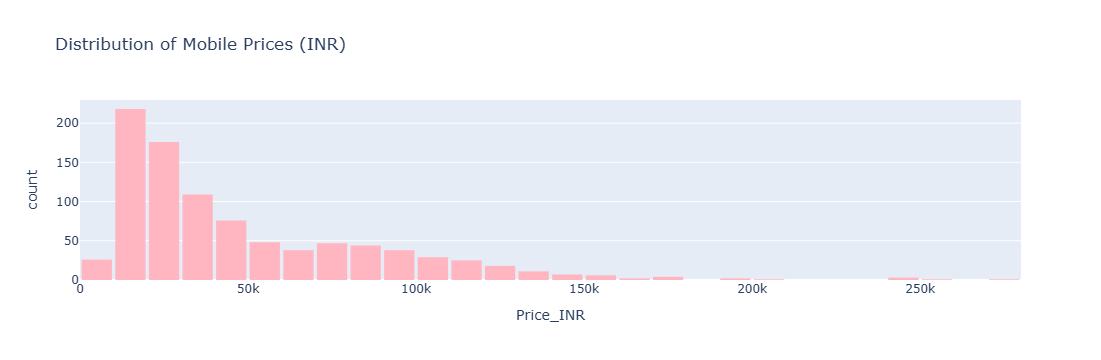

In [53]:
fig = px.histogram(data, x="Price_INR", nbins=40, color_discrete_sequence=['lightpink'],
                   title="Distribution of Mobile Prices (INR)")
fig.update_layout(bargap=0.1)
fig.show()


### 3️⃣ RAM vs Price with trend line

In [58]:
import re

# Convert "6GB", "8 GB", "12GB/128GB" → numeric RAM (in GB)
def parse_ram(x):
    if pd.isna(x):
        return None
    m = re.search(r'(\d+(\.\d+)?)\s*GB', str(x))
    if m:
        return float(m.group(1))
    return None

data["RAM_GB"] = data["RAM"].apply(parse_ram)
print(data["RAM_GB"].head(10))


0    6.0
1    6.0
2    6.0
3    6.0
4    6.0
5    6.0
6    6.0
7    8.0
8    8.0
9    6.0
Name: RAM_GB, dtype: float64


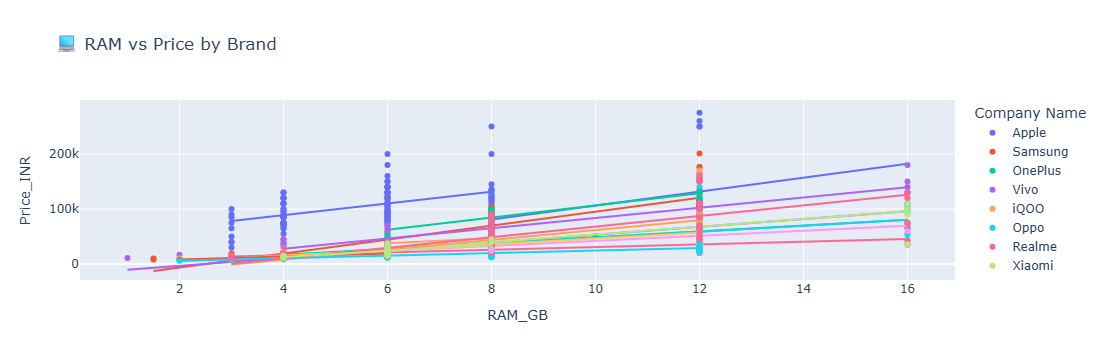

In [60]:
import plotly.express as px

fig = px.scatter(
    data,
    x="RAM_GB",
    y="Price_INR",
    color="Company Name",
    title="💻 RAM vs Price by Brand",
    trendline="ols",
    hover_data=["Model Name"]
)
fig.show()


### 4️⃣ Battery vs Price

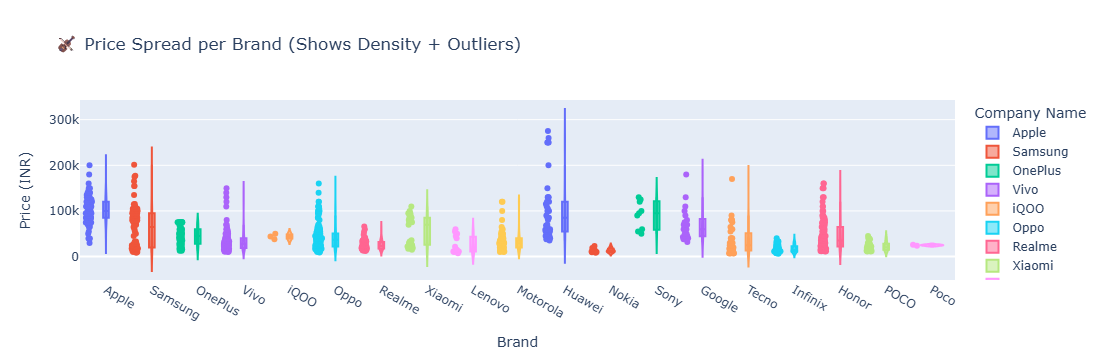

In [65]:
fig = px.violin(
    data,
    x="Company Name",
    y="Price_INR",
    color="Company Name",
    box=True,
    points="all",
    title="🎻 Price Spread per Brand (Shows Density + Outliers)"
)
fig.update_layout(xaxis_title="Brand", yaxis_title="Price (INR)")
fig.show()

---violin plot


In [69]:
print(data.columns.tolist())

----bubble plot


['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Price_PKR', 'Price_INR', 'Price_CNY', 'Price_USD', 'Price_AED', 'Launched Year', 'RAM_GB']


In [71]:
import re

def parse_battery(x):
    if pd.isna(x):
        return None
    m = re.search(r'(\d+)', str(x).replace(',', ''))
    if m:
        return float(m.group(1))
    return None

data["Battery_mAh"] = data["Battery Capacity"].apply(parse_battery)
print(data["Battery_mAh"].head(10))


0    3600.0
1    3600.0
2    3600.0
3    4200.0
4    4200.0
5    4200.0
6    4400.0
7    4400.0
8    4400.0
9    4500.0
Name: Battery_mAh, dtype: float64


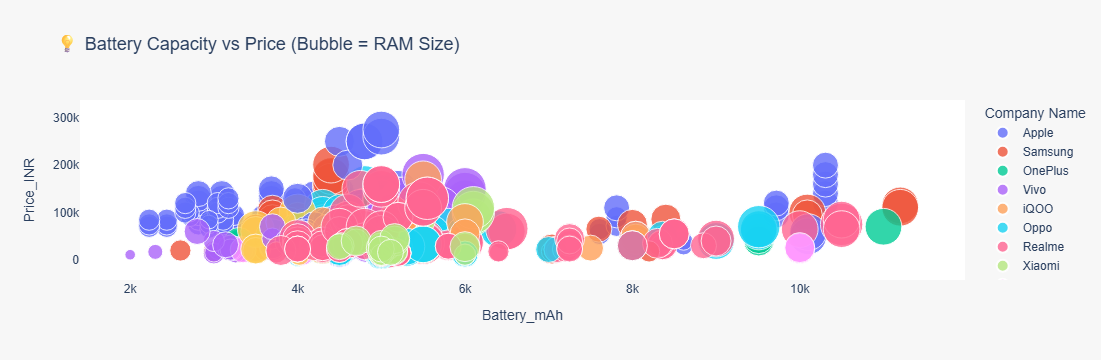

In [73]:
import plotly.express as px

fig = px.scatter(
    data,
    x="Battery_mAh",
    y="Price_INR",
    size="RAM_GB",                # Bubble size = RAM
    color="Company Name",
    hover_name="Model Name",
    title="💡 Battery Capacity vs Price (Bubble = RAM Size)",
    size_max=30,
    opacity=0.8,
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="#f7f7f7",
    title_font_size=18,
    font=dict(family="Arial", size=12)
)
fig.show()


### 5️⃣ Screen size vs Price (bubble by RAM)

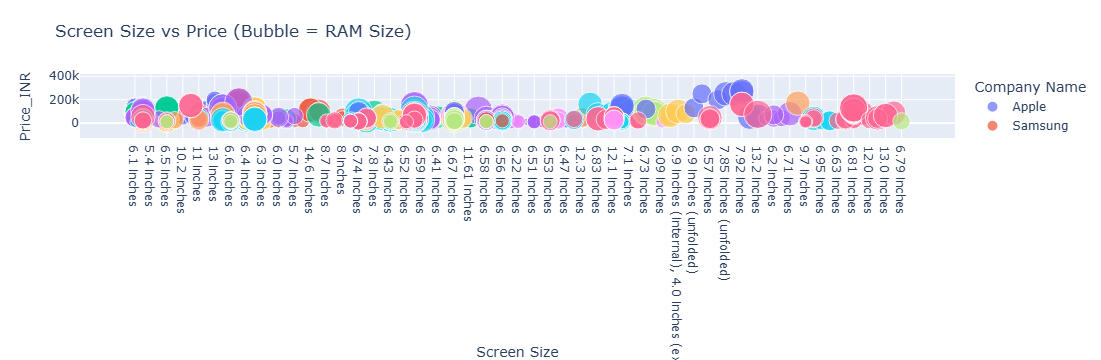

In [78]:
fig = px.scatter(data, x="Screen Size", y="Price_INR", size="RAM_GB",
                 color="Company Name", hover_name="Model Name",
                 title="Screen Size vs Price (Bubble = RAM Size)")
fig.show()

### 6️⃣ Heatmap of correlations (matplotlib)

✅ Data cleaned successfully!
  Company Name            Model Name  RAM_GB  Battery_mAh  Screen_in  \
0        Apple       iPhone 16 128GB     6.0       3600.0        6.1   
1        Apple       iPhone 16 256GB     6.0       3600.0        6.1   
2        Apple       iPhone 16 512GB     6.0       3600.0        6.1   
3        Apple  iPhone 16 Plus 128GB     6.0       4200.0        6.7   
4        Apple  iPhone 16 Plus 256GB     6.0       4200.0        6.7   

   Weight_g  Price_INR  
0     174.0    79999.0  
1     174.0    84999.0  
2     174.0    89999.0  
3     203.0    89999.0  
4     203.0    94999.0  


C:\Users\guddi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.



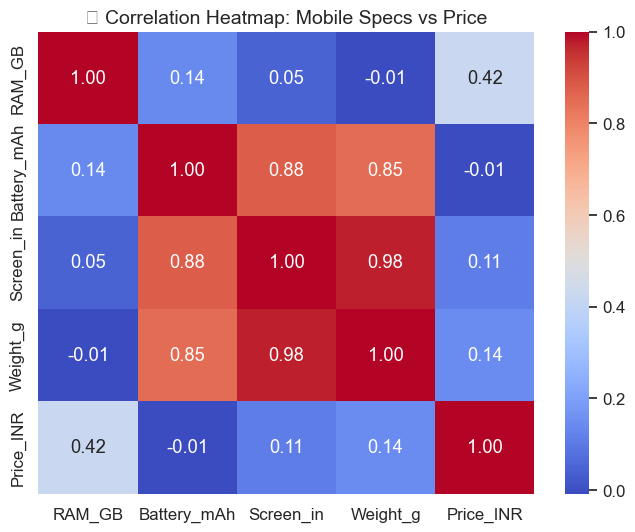


📈 Correlation of each feature with Price (INR):

Price_INR      1.000000
RAM_GB         0.422144
Weight_g       0.141899
Screen_in      0.108592
Battery_mAh   -0.007829
Name: Price_INR, dtype: float64

📊 Model Performance:
MAE  (Mean Absolute Error): 25,629.68
RMSE (Root Mean Square Error): 33,992.20
R²   (R-squared): 0.288


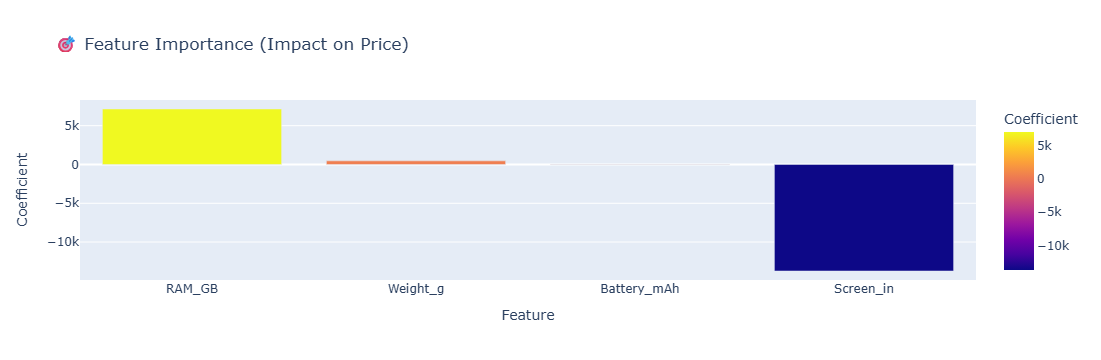

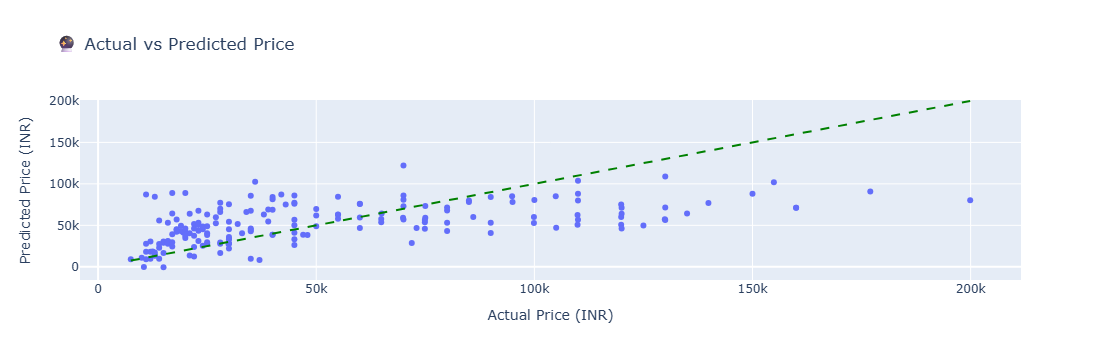


✅ Cleaned dataset saved as 'mobiles_cleaned_ready.csv'


In [199]:
# 📦 Imports
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------------------------
# 1️⃣ Load dataset
# -----------------------------------------------
data =pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")

# -----------------------------------------------
# 2️⃣ Data Cleaning
# -----------------------------------------------
def extract_number(x):
    """Extract numeric values from strings like '6.1 inches', '4200mAh', '8GB', etc."""
    if pd.isna(x):
        return None
    x = str(x).replace(',', '')
    m = re.search(r'(\d+(\.\d+)?)', x)
    return float(m.group(1)) if m else None

# Clean all numeric fields
data["RAM_GB"] = data["RAM"].apply(extract_number)
data["Battery_mAh"] = data["Battery Capacity"].apply(extract_number)
data["Screen_in"] = data["Screen Size"].apply(extract_number)
data["Weight_g"] = data["Mobile Weight"].apply(extract_number)

# Clean price (India) column
def clean_price(x):
    if pd.isna(x): return None
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)
    try:
        return float(x)
    except:
        return None

data["Price_INR"] = data["Launched Price (India)"].apply(clean_price)

# Drop rows with missing essential data
data = data.dropna(subset=["Price_INR","RAM_GB","Battery_mAh","Screen_in"])

print("✅ Data cleaned successfully!")
print(data[["Company Name","Model Name","RAM_GB","Battery_mAh","Screen_in","Weight_g","Price_INR"]].head())

# -----------------------------------------------
# 3️⃣ Correlation Heatmap
# -----------------------------------------------
corr = data[["RAM_GB","Battery_mAh","Screen_in","Weight_g","Price_INR"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("📊 Correlation Heatmap: Mobile Specs vs Price", fontsize=14)
plt.show()

# Show correlation with price only
print("\n📈 Correlation of each feature with Price (INR):\n")
print(corr["Price_INR"].sort_values(ascending=False))

# -----------------------------------------------
# 4️⃣ Predictive Model: Linear Regression
# -----------------------------------------------
X = data[["RAM_GB","Battery_mAh","Screen_in","Weight_g"]]
y = data["Price_INR"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -----------------------------------------------
# 5️⃣ Model Evaluation
# -----------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Model Performance:")
print(f"MAE  (Mean Absolute Error): {mae:,.2f}")
print(f"RMSE (Root Mean Square Error): {rmse:,.2f}")
print(f"R²   (R-squared): {r2:.3f}")


# -----------------------------------------------
# 6️⃣ Feature Importance
# -----------------------------------------------
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

fig = px.bar(
    importance,
    x="Feature",
    y="Coefficient",
    color="Coefficient",
    color_continuous_scale="Plasma",
    title="🎯 Feature Importance (Impact on Price)"
)
fig.show()

# -----------------------------------------------
# 7️⃣ Actual vs Predicted Visualization
# -----------------------------------------------
fig = px.scatter(
    x=y_test, y=y_pred,
    labels={'x':'Actual Price (INR)', 'y':'Predicted Price (INR)'},
    title="🔮 Actual vs Predicted Price"
)
fig.add_shape(
    type="line", x0=y_test.min(), y0=y_test.min(), x1=y_test.max(), y1=y_test.max(),
    line=dict(color="green", dash="dash")
)
fig.show()

# -----------------------------------------------
# 8️⃣ Save Model Output (Optional)
# -----------------------------------------------
data.to_csv("mobiles_cleaned_ready.csv", index=False)
print("\n✅ Cleaned dataset saved as 'mobiles_cleaned_ready.csv'")


In [197]:
# -----------------------------------------------
# 4️⃣ Predictive Model: Linear Regression
# -----------------------------------------------
X = data[["RAM_GB","Battery_mAh","Screen_in","Weight_g"]]
y = data["Price_INR"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -----------------------------------------------
# 5️⃣ Model Evaluation
# -----------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Model Performance:")
print(f"MAE  (Mean Absolute Error): {mae:,.2f}")
print(f"RMSE (Root Mean Square Error): {rmse:,.2f}")
print(f"R²   (R-squared): {r2:.3f}")



📊 Model Performance:
MAE  (Mean Absolute Error): 25,629.68
RMSE (Root Mean Square Error): 33,992.20
R²   (R-squared): 0.288


C:\Users\guddi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 127752 (\N{RAINBOW}) missing from font(s) Arial.



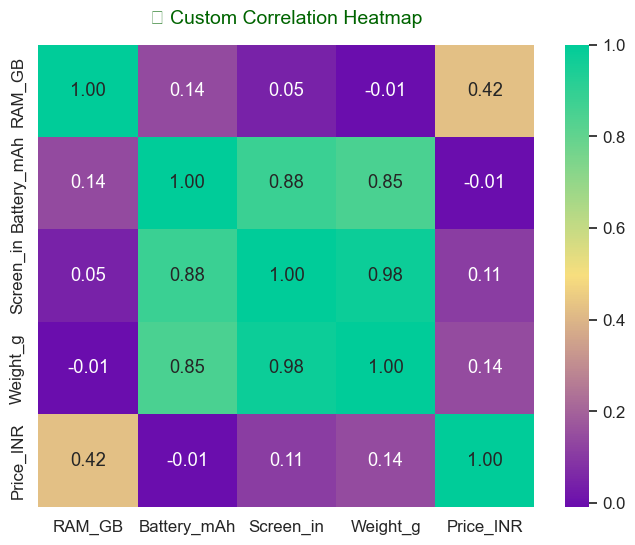

In [95]:
from matplotlib.colors import LinearSegmentedColormap

# Create custom gradient (purple → yellow → green)
custom_cmap = LinearSegmentedColormap.from_list("custom", ["#6a0dad", "#f8de7e", "#00cc99"])

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap=custom_cmap, fmt=".2f")
plt.title("🌈 Custom Correlation Heatmap", fontsize=14, pad=15, color='darkgreen')
plt.show()

sns.set_style("whitegrid")
sns.set(font_scale=1.1)

In [91]:
sns.set_style("whitegrid")
sns.set(font_scale=1.1)

### 7️⃣ Yearly launch trend

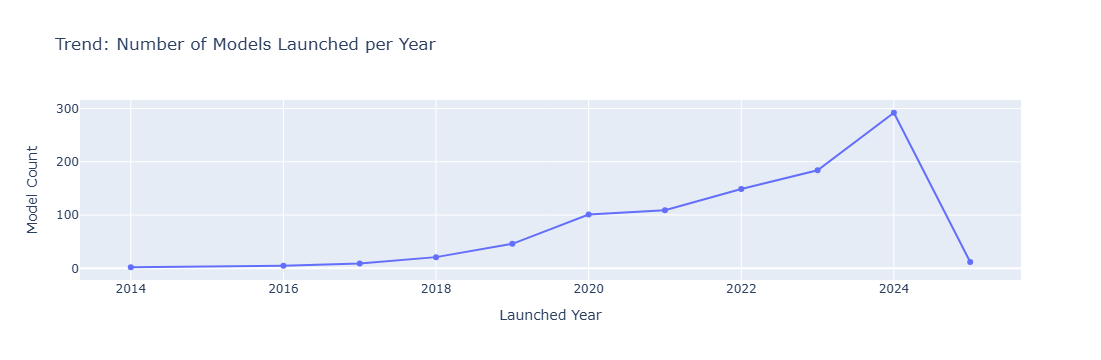

In [102]:
yearly = data.groupby("Launched Year").size().reset_index(name="Model Count")
fig = px.line(yearly, x="Launched Year", y="Model Count",
              title="Trend: Number of Models Launched per Year",
              markers=True)
fig.show()


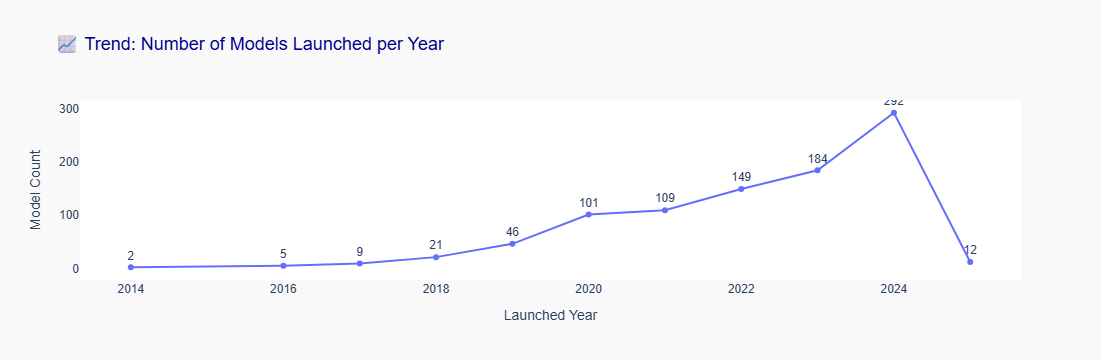

In [104]:
yearly = data.groupby("Launched Year").size().reset_index(name="Model Count")

fig = px.line(
    yearly,
    x="Launched Year",
    y="Model Count",
    title="📈 Trend: Number of Models Launched per Year",
    markers=True,
    text="Model Count"      # 👈 this adds the label text for each marker
)

# Show labels above the points
fig.update_traces(textposition="top center")

# Optional layout styling
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="#f9f9f9",
    font=dict(family="Arial", size=12),
    title_font=dict(size=18, color="darkblue")
)

fig.show()


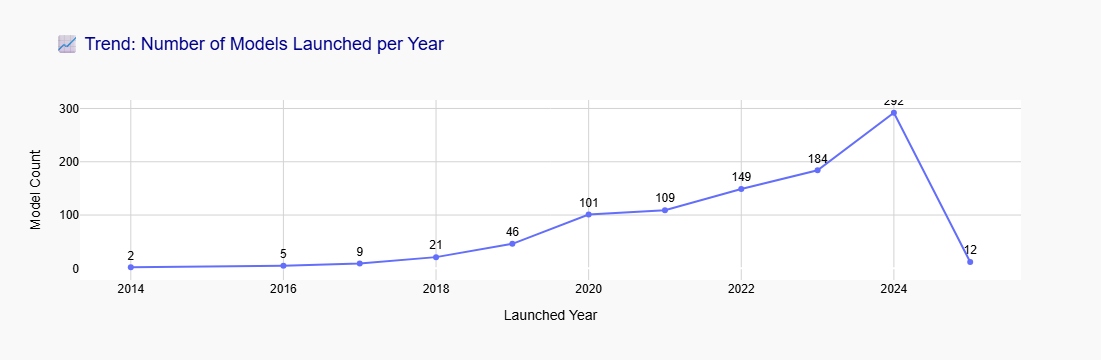

In [108]:
yearly = data.groupby("Launched Year").size().reset_index(name="Model Count")

fig = px.line(
    yearly,
    x="Launched Year",
    y="Model Count",
    title="📈 Trend: Number of Models Launched per Year",
    markers=True,
    text="Model Count"  # Add labels
)

# Show text above markers
fig.update_traces(textposition="top center")

# Turn ON grids and style them
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

# Background & font style
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="#f9f9f9",
    font=dict(family="Arial", size=12, color="black"),
    title_font=dict(size=18, color="darkblue"),
)

fig.show()





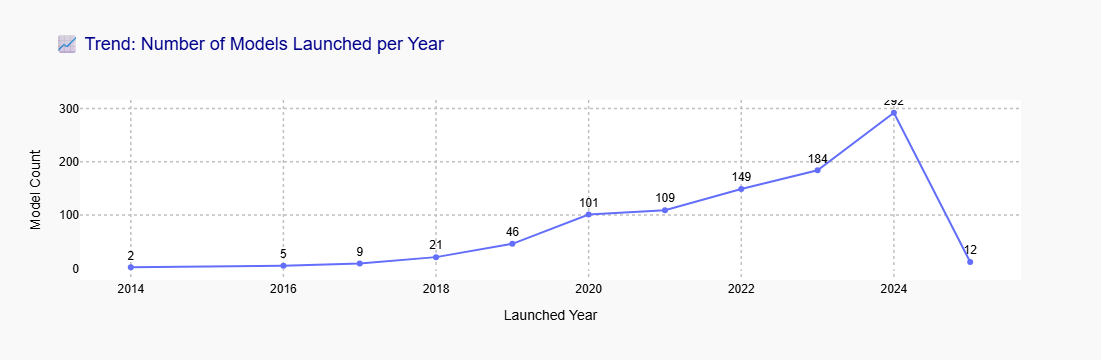

In [110]:
fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray', griddash='dot')
fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray', griddash='dot')


fig.update_xaxes(showgrid=True, gridwidth=1.5, gridcolor='silver')
fig.update_yaxes(showgrid=True, gridwidth=1.5, gridcolor='silver')

## Predictive Modelling (Price Prediction)

In [113]:
# Select features and drop rows with missing numeric values
model_data = data[['Price_INR','RAM_GB','Battery_mAh','Screen_in','Weight_g']].dropna()

X = model_data[['RAM_GB','Battery_mAh','Screen_in','Weight_g']]
y = model_data['Price_INR']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR² Score: {r2:.2f}")


Model Performance:
MAE: 25629.68
RMSE: 33992.20
R² Score: 0.29


C:\Users\guddi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



In [115]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)
coef_df


,Feature,Coefficient
0,RAM_GB,7153.326553
3,Weight_g,466.847358
1,Battery_mAh,-19.036118
2,Screen_in,-13734.727523


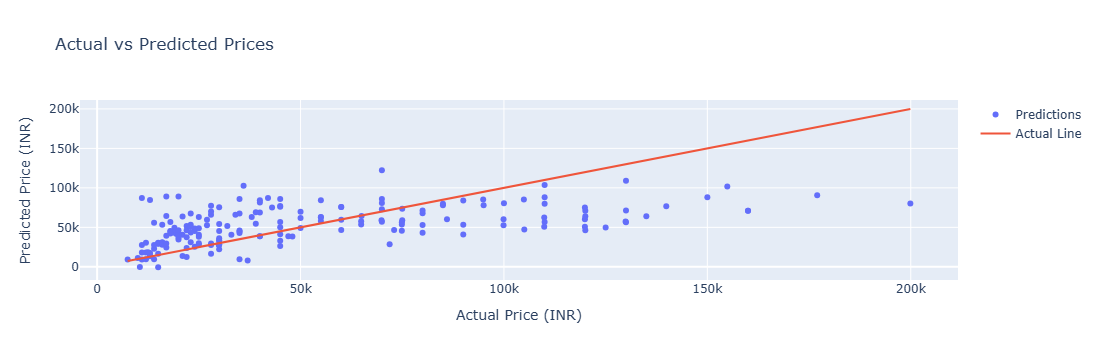

In [117]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_test, y=y_pred, mode='markers', name='Predictions'))
fig.add_trace(go.Scatter(x=y_test, y=y_test, mode='lines', name='Actual Line'))
fig.update_layout(title="Actual vs Predicted Prices",
                  xaxis_title="Actual Price (INR)",
                  yaxis_title="Predicted Price (INR)")
fig.show()


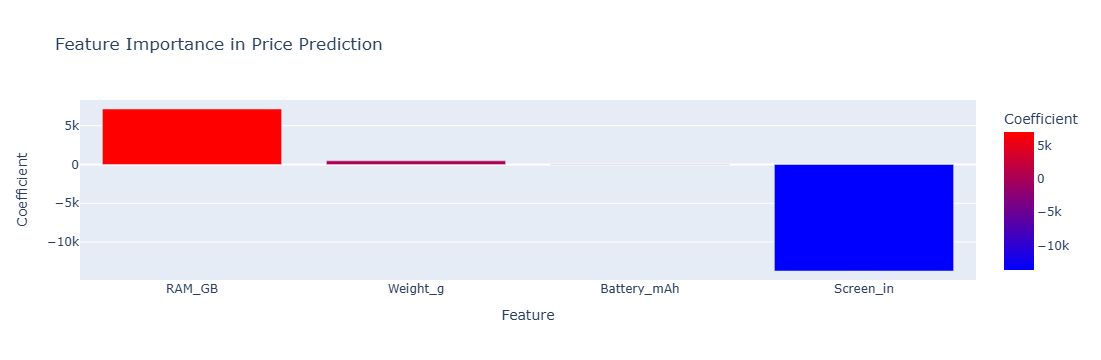

In [119]:
fig = px.bar(coef_df, x="Feature", y="Coefficient", color="Coefficient",
             title="Feature Importance in Price Prediction",
             color_continuous_scale="Bluered")
fig.show()


##### ✅ R² value (if around 0.6–0.8) means model captures moderate to strong relationships — good for linear regression on real-world pricing data.

#### Price comparison across countries

In [131]:
import re
import numpy as np

def clean_price(val):
    """Cleans a price column and extracts numeric value."""
    # If the entire column was accidentally passed, skip
    if isinstance(val, pd.Series):
        return val.apply(clean_price)

    if pd.isna(val):
        return np.nan

    s = str(val)
    # Remove all non-numeric characters except dots
    s = re.sub(r'[^0-9.]', '', s)
    try:
        return float(s)
    except:
        return np.nan


In [133]:
price_columns = [
    'Launched Price (Pakistan)',
    'Launched Price (India)',
    'Launched Price (China)',
    'Launched Price (USA)',
    'Launched Price (Dubai)'
]

# Rename them for convenience
data = data.rename(columns={
    "Launched Price (Pakistan)": "Price_PKR",
    "Launched Price (India)": "Price_INR",
    "Launched Price (China)": "Price_CNY",
    "Launched Price (USA)": "Price_USD",
    "Launched Price (Dubai)": "Price_AED"
})

# Apply cleaning only if the column exists
for col in ['Price_PKR','Price_INR','Price_CNY','Price_USD','Price_AED']:
    if col in data.columns:
        data[col] = data[col].map(clean_price)

print("✅ All price columns cleaned and converted to numeric!")


✅ All price columns cleaned and converted to numeric!


In [135]:
data[['Price_PKR','Price_INR','Price_CNY','Price_USD','Price_AED']].head(10)


,Price_PKR,Price_INR,Price_INR,Price_CNY,Price_USD,Price_AED
0,224999.0,79999.0,79999.0,5799.0,799.0,2799.0
1,234999.0,84999.0,84999.0,6099.0,849.0,2999.0
2,244999.0,89999.0,89999.0,6499.0,899.0,3199.0
3,249999.0,89999.0,89999.0,6199.0,899.0,3199.0
4,259999.0,94999.0,94999.0,6499.0,949.0,3399.0
5,274999.0,104999.0,104999.0,6999.0,999.0,3599.0
6,284999.0,99999.0,99999.0,6999.0,999.0,3499.0
7,294999.0,104999.0,104999.0,7099.0,1049.0,3699.0
8,314999.0,114999.0,114999.0,7499.0,1099.0,3899.0
9,314999.0,109999.0,109999.0,7499.0,1099.0,3799.0


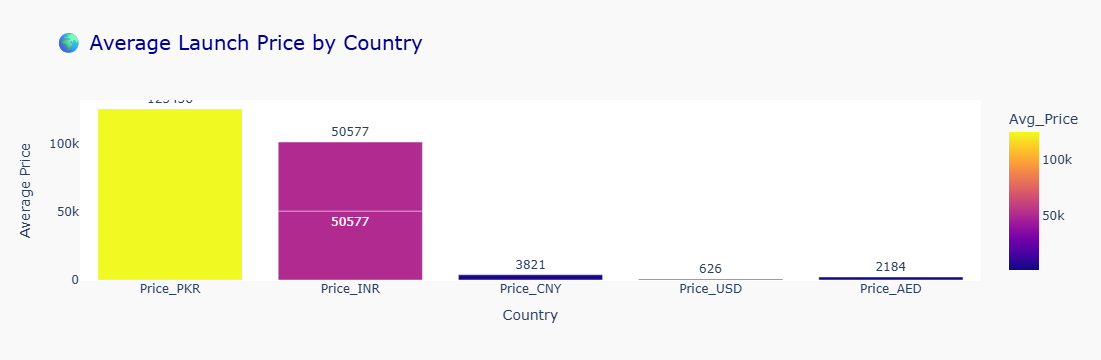

In [137]:
import plotly.express as px

price_cols = ['Price_PKR','Price_INR','Price_CNY','Price_USD','Price_AED']
country_prices = data[price_cols].mean().reset_index()
country_prices.columns = ['Country','Avg_Price']

fig = px.bar(
    country_prices,
    x='Country',
    y='Avg_Price',
    color='Avg_Price',
    text='Avg_Price',
    title='🌍 Average Launch Price by Country',
    color_continuous_scale='Plasma'
)

fig.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="#f9f9f9",
    xaxis_title="Country",
    yaxis_title="Average Price",
    title_font=dict(size=20, color='darkblue'),
    font=dict(size=12)
)
fig.show()


#### Top 10 premium phones (₹)

In [143]:
print(data.columns.tolist())


['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Price_PKR', 'Price_INR', 'Price_CNY', 'Price_USD', 'Price_AED', 'Launched Year', 'RAM_GB', 'Battery_mAh', 'Screen_in', 'Weight_g', 'Price_INR']


In [194]:
duplicates = data.columns[data.columns.duplicated()].tolist()
print("🔍 Duplicate columns:", duplicates)


🔍 Duplicate columns: []


In [157]:
from collections import Counter

counts = Counter()
new_columns = []
for col in data.columns:
    counts[col] += 1
    new_columns.append(col if counts[col] == 1 else f"{col}.{counts[col]-1}")

data.columns = new_columns
print("✅ Duplicates fixed! New columns:")
print(data.columns.tolist())


✅ Duplicates fixed! New columns:
['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Price_PKR', 'Price_INR', 'Price_CNY', 'Price_USD', 'Price_AED', 'Launched Year', 'RAM_GB', 'Battery_mAh', 'Screen_in', 'Weight_g']


In [159]:
print(data.columns[data.columns.duplicated()])


Index([], dtype='object')


In [163]:
premium = (
    data[['Company Name','Model Name','Price_INR']]
    .dropna()
    .sort_values('Price_INR', ascending=False)
    .head(10)
)

In [167]:
premium = (
    data[['Company Name','Model Name','Price_INR']]
    .dropna()
    .sort_values('Price_INR', ascending=False)
    .head(10)
)

premium


,Company Name,Model Name,Price_INR
661,Huawei,Mate XT 512GB,274999.0
660,Huawei,Mate XT 256GB,259999.0
643,Huawei,Mate X3,249999.0
630,Huawei,Mate X2,249999.0
657,Huawei,Mate X6,249999.0
929,Samsung,Galaxy Z Fold6 1TB,200999.0
634,Huawei,Mate Xs 2,199999.0
96,Apple,iPad Pro 13-inch 2TB,199900.0
708,Google,Pixel 9 Pro Fold 512GB,179999.0
95,Apple,iPad Pro 13-inch 1TB,179900.0


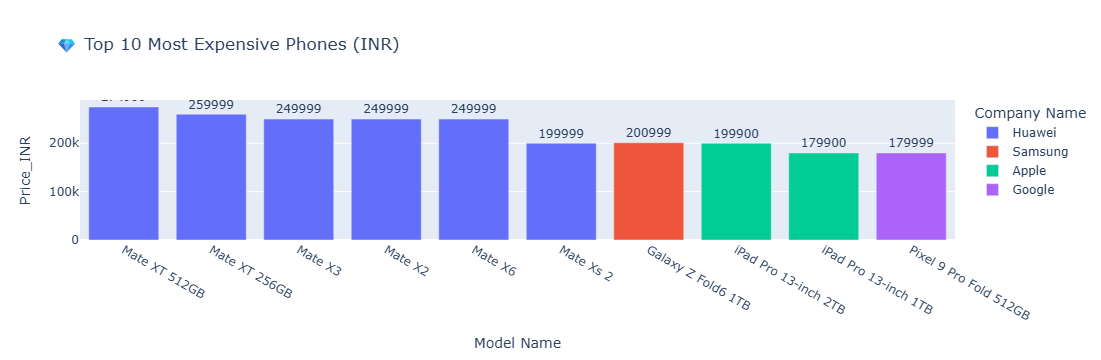

In [173]:
import plotly.express as px

fig = px.bar(
    premium,
    x='Model Name',
    y='Price_INR',
    color='Company Name',
    title='💎 Top 10 Most Expensive Phones (INR)',
    text='Price_INR'
)
fig.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig.show()


In [177]:
premium = (
    data[['Company Name','Model Name','Price_INR']]
    .dropna()
    .sort_values('Price_INR', ascending=False)
    .head(10)
)


In [179]:
def highlight_top3(row):
    # Highlight top 3 most expensive phones in light gold
    color = 'background-color: #ffe08a' if row.name < 3 else ''
    return [color] * len(row)

styled = (
    premium.style
    .apply(highlight_top3, axis=1)
    .background_gradient(subset=['Price_INR'], cmap='Reds')
    .format({'Price_INR': '₹{:,.0f}'})  # adds ₹ and commas
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#003366'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #ccc'), ('padding', '6px')]}
    ])
    .set_caption("💎 Top 10 Most Expensive Phones (Styled)")
)
styled


,Company Name,Model Name,Price_INR
661,Huawei,Mate XT 512GB,"₹274,999"
660,Huawei,Mate XT 256GB,"₹259,999"
643,Huawei,Mate X3,"₹249,999"
630,Huawei,Mate X2,"₹249,999"
657,Huawei,Mate X6,"₹249,999"
929,Samsung,Galaxy Z Fold6 1TB,"₹200,999"
634,Huawei,Mate Xs 2,"₹199,999"
96,Apple,iPad Pro 13-inch 2TB,"₹199,900"
708,Google,Pixel 9 Pro Fold 512GB,"₹179,999"
95,Apple,iPad Pro 13-inch 1TB,"₹179,900"


###### ✅ Output:

Red color intensity = higher price

Top 3 highlighted gold ✨

₹ symbol + thousand separator

Dark blue header with white text

In [182]:
styled_brand = (
    premium.style
    .background_gradient(subset=['Price_INR'], cmap='Blues')
    .apply(lambda x: ['background-color: #e6f2ff' if x['Company Name'] == 'Apple' else '' for _ in x], axis=1)
    .format({'Price_INR': '₹{:,.0f}'})
    .hide(axis='index')
    .set_caption("📱 Price Comparison by Brand (Custom Colors)")
)
styled_brand


Company Name,Model Name,Price_INR
Huawei,Mate XT 512GB,"₹274,999"
Huawei,Mate XT 256GB,"₹259,999"
Huawei,Mate X3,"₹249,999"
Huawei,Mate X2,"₹249,999"
Huawei,Mate X6,"₹249,999"
Samsung,Galaxy Z Fold6 1TB,"₹200,999"
Huawei,Mate Xs 2,"₹199,999"
Apple,iPad Pro 13-inch 2TB,"₹199,900"
Google,Pixel 9 Pro Fold 512GB,"₹179,999"
Apple,iPad Pro 13-inch 1TB,"₹179,900"


In [184]:
styled_bar = (
    premium.style
    .bar(subset=['Price_INR'], color='#ffb347')  # orange bar
    .format({'Price_INR': '₹{:,.0f}'})
    .set_properties(**{'text-align': 'center'})
    .set_caption("📊 Price Bars — Visualized Inside the Table")
)
styled_bar


,Company Name,Model Name,Price_INR
661,Huawei,Mate XT 512GB,"₹274,999"
660,Huawei,Mate XT 256GB,"₹259,999"
643,Huawei,Mate X3,"₹249,999"
630,Huawei,Mate X2,"₹249,999"
657,Huawei,Mate X6,"₹249,999"
929,Samsung,Galaxy Z Fold6 1TB,"₹200,999"
634,Huawei,Mate Xs 2,"₹199,999"
96,Apple,iPad Pro 13-inch 2TB,"₹199,900"
708,Google,Pixel 9 Pro Fold 512GB,"₹179,999"
95,Apple,iPad Pro 13-inch 1TB,"₹179,900"


# extra

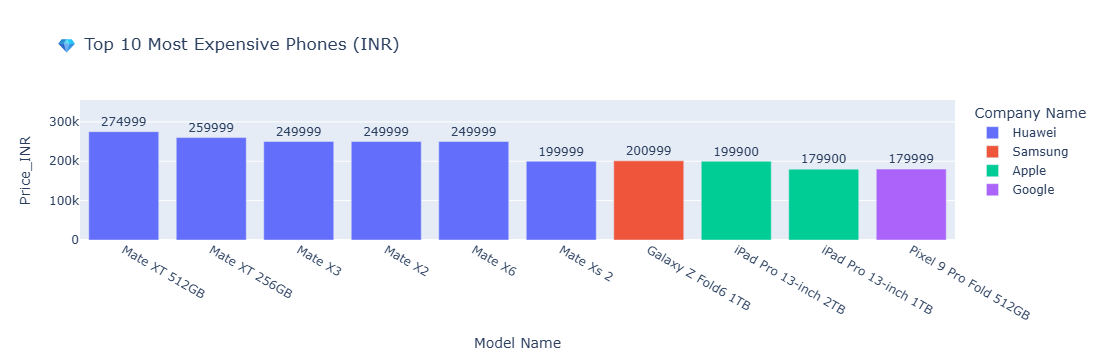

,Company Name,Model Name,Price_INR
661,Huawei,Mate XT 512GB,"₹274,999"
660,Huawei,Mate XT 256GB,"₹259,999"
643,Huawei,Mate X3,"₹249,999"
630,Huawei,Mate X2,"₹249,999"
657,Huawei,Mate X6,"₹249,999"
929,Samsung,Galaxy Z Fold6 1TB,"₹200,999"
634,Huawei,Mate Xs 2,"₹199,999"
96,Apple,iPad Pro 13-inch 2TB,"₹199,900"
708,Google,Pixel 9 Pro Fold 512GB,"₹179,999"
95,Apple,iPad Pro 13-inch 1TB,"₹179,900"


In [192]:
import plotly.express as px
from IPython.display import display

fig = px.bar(
    premium,
    x='Model Name',
    y='Price_INR',
    color='Company Name',
    title='💎 Top 10 Most Expensive Phones (INR)',
    text='Price_INR'
)
fig.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig.update_layout(plot_bgcolor="light blue")

fig.show()
display(styled)
